# Spectral density as a function of $U_{IB}$ #

In [1]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import matplotlib
import h5py
import numpy as np
import class_utils as class_utils
from class_grid import Grid
from class_params import Params
from class_groundstate import groundstate
from class_excitations import excitations
from class_vertices import vertices
from class_perturbation import perturbative
from class_self_energy import Self_Energy
from class_io import IO
from class_plotting import plot2D, plot_cns, plot_omega0
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker


### For different $U_{IB}$ values

In [2]:
config_path = "config.yml" 

# 0.1723, 0.4142
# 0.2154, 0.4014

dJU = 0.2154 #(np.sqrt(2) - 1)**2 + 0.01 # which hopping value are we fixing to
muU = 0.4014 # which chemical potential we are fixing to

output_dir = class_utils.create_output_dir()
config = class_utils.read_config(config_path)

Lx = config["grid"]["Lx"]
Ly = config["grid"]["Ly"]
cutoff = config["physics"]["cutoff"]
N = config["physics"]["N"]
M = Lx * Ly

grid = Grid(Lx, Ly)

# num_en = 400 #150 # 100
# num_UIB = 200 # 100
# en_vector = np.linspace(-4,1.5,num_en)
# UIBs = np.linspace(-2, 2, num_UIB)
num_en = 400 #150 # 100
num_UIB = 200 # 100
en_vector = np.linspace(-4,1.5,num_en)
UIBs = np.linspace(-2, 2, num_UIB)

In [3]:
### RUN THIS BLOCK IF LOADING FROM A FILE. ###

input("confirm data is to be loaded.")

#filename = f'./data/self_consistent_t/ladder_full_mf_init/UIB_scan/dJU_0.1292_Mu_0.41_M_16_N_7_num_en_100_num_UIB_100_eta_0.01_cutoff_3_n_1.hdf5'
filename = f'./data/self_consistent_t/ladder_full_mf_init/UIB_scan/dJU_0.1292_Mu_0.41_M_100_N_7_num_en_400_num_UIB_200_eta_0.01_cutoff_3_n_1.hdf5'
with h5py.File(filename, 'r') as f:
    UIBs = f['UIBs'][:]
    en_vector = f['en_vector'][:]
    omega0s = f['omega0s'][:]
    omega1s = f['omega1s'][:]
    omega2s = f['omega2s'][:]

    T11 = []
    T12 = []
    T21 = []
    T22 = []
    T22_F = []
    SE_SI = []

    for count, UIB in enumerate(UIBs):
        group = f[f'UIB_{UIB}']
        T11.append(group['T11'][:])
        T12.append(group['T12'][:])
        T21.append(group['T21'][:])
        T22.append(group['T22'][:])
        T22_F.append(group['T22_SE'][:])
        SE_SI.append(group['SE_SI'][:])

KeyboardInterrupt: Interrupted by user

In [3]:
# run this block if you are making the data for the first time

input("confirm that you would like to make the data for the first time")

omega0s = np.zeros(len(UIBs))
omega1s = np.zeros(len(UIBs))
omega2s = np.zeros(len(UIBs))

SE = np.zeros((7, len(en_vector)), dtype=np.complex128)  #7 rows for each contribution, num_en columns 
SE_NSC = SE

#V:  Add poles to this plot!!!
T11 = np.zeros((len(UIBs), len(en_vector)), dtype=np.complex128)
T12 = np.zeros((len(UIBs), len(en_vector)), dtype=np.complex128)
T21 = np.zeros((len(UIBs), len(en_vector)), dtype=np.complex128)
T22 = np.zeros((len(UIBs), len(en_vector)), dtype=np.complex128)
T22_F = np.zeros((len(UIBs), len(en_vector)), dtype=np.complex128)
SE_SI = np.zeros((len(UIBs), len(en_vector)), dtype=np.complex128)

for count, UIB in enumerate(UIBs):
    params = Params(N, dJU, muU, UIB, cutoff)
    print(count,UIB)
    gs = groundstate(params)
    cns = gs.cns()
    n0 = gs.n0(cns)
    psi0 = gs.psi0(cns)
    exc = excitations(grid, params, gs, cns)
    uks, vks, omegaklambda = exc.calculate_matrices()
    verts = vertices(grid, gs, uks, vks, cns, n0)
    pert = perturbative(grid, params, verts, omegaklambda)
    Pert_Energy = pert.perturbative_energy(n0)
    omega0s[count] = Pert_Energy[0]
    omega1s[count] = Pert_Energy[1]
    omega2s[count] = Pert_Energy[2]

    for epol_ind in range(len(en_vector)):
        # # Non-self consistent
        # Epol_NSC = en_vector[epol_ind] - UIB # 0th iteration has mean-field energy for the self energy.
        # self_energy = Self_Energy(Epol_NSC, grid, params, verts, omegaklambda)
        # output_NSC = self_energy.calculate_self_energy()
        # # Self consistent
        Epol_SC = en_vector[epol_ind] -UIB #- output_NSC[6]
        self_energy = Self_Energy(Epol_SC, grid, params, verts, omegaklambda)
        output_SC = self_energy.calculate_self_energy()
        SE[:, epol_ind] = output_SC
    #The zeroth element is the full self energy minus w, used for finding the zero crossings.
    T11[count, :] = SE[1, :]
    T12[count, :] = SE[2, :]
    T21[count, :] = SE[3, :]
    T22[count, :] = SE[4, :]
    T22_F[count, :] = SE[5, :]
    SE_SI[count, :] = SE[6, :]

confirm that you would like to make the data for the first time 


0 -2.0
1 -1.979899497487437
2 -1.9597989949748744
3 -1.9396984924623115
4 -1.9195979899497488
5 -1.899497487437186
6 -1.879396984924623
7 -1.8592964824120604
8 -1.8391959798994975
9 -1.8190954773869348
10 -1.7989949748743719
11 -1.778894472361809
12 -1.7587939698492463
13 -1.7386934673366834
14 -1.7185929648241207
15 -1.6984924623115578
16 -1.678391959798995
17 -1.6582914572864322
18 -1.6381909547738693
19 -1.6180904522613067
20 -1.5979899497487438
21 -1.5778894472361809
22 -1.557788944723618
23 -1.5376884422110553
24 -1.5175879396984926
25 -1.4974874371859297
26 -1.4773869346733668
27 -1.457286432160804
28 -1.4371859296482412
29 -1.4170854271356785
30 -1.3969849246231156
31 -1.3768844221105527
32 -1.3567839195979898
33 -1.3366834170854272
34 -1.3165829145728645
35 -1.2964824120603016
36 -1.2763819095477387
37 -1.2562814070351758
38 -1.236180904522613
39 -1.2160804020100502
40 -1.1959798994974875
41 -1.1758793969849246
42 -1.1557788944723617
43 -1.135678391959799
44 -1.1155778894472361

In [4]:
# construct the spectral function and self energy 
SpectralFuncs = np.zeros((len(UIBs), len(en_vector)), dtype = float)
Sigma = np.zeros((len(UIBs), len(en_vector)),dtype=np.complex128)
Sigma00 = np.zeros((len(UIBs), len(en_vector)),dtype=np.complex128)
#UIB_map = UIBs * np.ones_like(SpectralFuncs)
dOmega = en_vector[1] - en_vector[0]
eta = 0.01

#
for count in range(0, len(UIBs)):
    SpectralFuncs[count, :] = dOmega * (-2) * np.imag(1./(en_vector - SE_SI[count] + 1j * eta))
    Sigma[count, :] = (T11[count] + T12[count] + T21[count]  + T22[count]) +  T22_F[count]
    Sigma00[count, :] = (T11[count] + T12[count] + T21[count]  + T22[count]) 
    

In [5]:
#Matija Data (Extrapolated, Complete June 19, 2024)
UIBs_M = np.array([-2,-1.8,-1.6,-1.4,-1.2,-1.0,-0.8,-0.6,-0.4,-0.2,0.0,0.2,0.4,0.6,0.8,1.0,1.2,1.4,1.6,1.8,2.0])
Ep_M_t_0p06 = np.array([-3.64868796158029,-3.0693461134484,-2.5501233402259,-2.09469009179096,-1.67784456439466,-1.28694495394565,-0.936821582186525,-0.653467128333918,-0.418359166399491,-0.203846841037217,0,0.19567833208015,0.37811851684933,0.524129913347533,0.589969873264466,0.605852250974881,0.613045506249879,0.618565115038529,0.623399177993451,0.626677951956117,0.629913078706734])
#Ep_M_error_t_0p06 = 
Ep_M_t_0p045 = np.array([-3.34760259720932,-2.7917082543896,-2.3303271384676,-1.9123297182468,-1.50719684797829,-1.11803404026707,-0.832360599990075,-0.612707795972141,-0.404664987987295,-0.201144820353729,0,0.198908752301098,0.395313756470703,0.586859621790816,0.745044451048733,0.760926744497953,0.757949806213547,0.758976484687154,0.7602408073182,0.761065483905998,0.762957235624749])
Ep_M_t_0p075 = np.array([-3.71328588779593,-3.14483168808094,-2.62258419432595,-2.1551068982953,-1.73262393074881,-1.34861869820071,-1.00442684678702,-0.70369039596017,-0.44212383269712,-0.210016564128341,0,0.189275780396277,0.352458736116826,0.47760910086735,0.558686911985995,0.605104950050664,0.634424001946133,0.653466838694103,0.667853028687259,0.677506556582985,0.686418902079267])


# UIBs_M = np.array([-1.0,-0.8,-0.6,-0.4,-0.2,0.0,0.2,0.4,0.6,0.8,1.0])
# Ep_M_t_0p075 = np.array([-1.34861869820071,-1.00442684678702,-0.70369039596017,-0.44212383269712,-0.210016564128341,0,0.189275780396277,0.352458736116826,0.47760910086735,0.558686911985995,0.605104950050664])
# #Ep_M_error_t_0p075 = np.array([7.30E-08,4.22E-08,2.41E-08,1.00E-08,2.24E-09,0,3.38E-09,1.31E-08,3.41E-08,6.72E-08,1.01E-07])
# #np.interp(-1.5,UIBs_M, Ep_M_t_0p045)


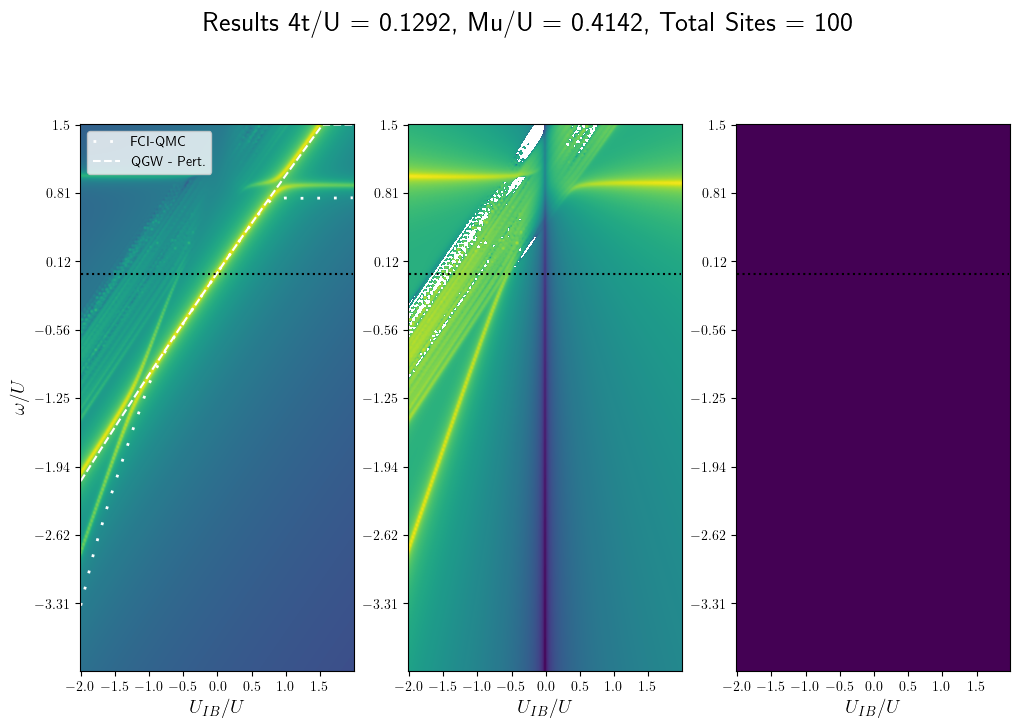

In [6]:

plt.rcParams['text.usetex'] = True

# Rotate the image by -90 degrees
SpectralFuncs_rot = np.rot90(SpectralFuncs, 1)
Sigma_rot = np.rot90(Sigma, 1)
Sigma00_rot = np.rot90(Sigma00, 1)


fig, (ax1, ax2, ax3) = plt.subplots(ncols = 3, figsize = (12,8))

# Create the plot
# Set the aspect ratio to the ratio of the number of x points to the number of y points
aspect_ratio = 1#'auto'#1
color_map = 'viridis' #'RdBu'
im1 = ax1.imshow(np.abs(SpectralFuncs_rot), interpolation = 'bicubic', cmap=color_map, aspect = aspect_ratio, norm=matplotlib.colors.LogNorm())
im2 = ax2.imshow(-2*np.imag(Sigma_rot), interpolation = 'bicubic',cmap=color_map, aspect = aspect_ratio, norm=matplotlib.colors.LogNorm())
im3 = ax3.imshow(-2*np.imag(Sigma00_rot), interpolation = 'bicubic',cmap=color_map, aspect = aspect_ratio)#,norm=matplotlib.colors.LogNorm())




# Select a subset of dJUs and en_vector for the ticks
num_xticks = 9
num_yticks = 9

xticks = np.linspace(0, SpectralFuncs_rot.shape[1], num_xticks, endpoint=True, dtype=int)
yticks = np.linspace(0, SpectralFuncs_rot.shape[0], num_yticks, endpoint=True, dtype=int)

xticklabels = np.round(np.linspace(min(UIBs), max(UIBs), num_xticks),2)
yticklabels = np.round(np.linspace(max(en_vector), min(en_vector), num_yticks), 2)

# Format the labels in LaTeX
xticklabels = [r'$\mathrm{{{}}}$'.format(label) for label in xticklabels]
yticklabels = [r'$\mathrm{{{}}}$'.format(label) for label in yticklabels]

ax1.set_xticks(xticks)
ax1.set_yticks(yticks)
ax2.set_xticks(xticks)
ax2.set_yticks(yticks)
ax3.set_xticks(xticks)
ax3.set_yticks(yticks)
ax1.set_xticklabels(xticklabels)
ax1.set_yticklabels(yticklabels)
ax2.set_xticklabels(xticklabels)
ax2.set_yticklabels(yticklabels)
ax3.set_xticklabels(xticklabels)
ax3.set_yticklabels(yticklabels)
ax1.set_xlabel(r'$U_{IB}/U$', fontsize=14)
ax2.set_xlabel(r'$U_{IB}/U$', fontsize=14)
ax3.set_xlabel(r'$U_{IB}/U$', fontsize=14)
ax1.set_ylabel(r'$\omega/U$', fontsize=14)

# cb1 = plt.colorbar(im1,orientation="horizontal")
# cb1.set_label(label="$A(0,\omega)$",size=15,weight='bold')
# cb2 = plt.colorbar(im2,orientation="horizontal")
# cb2.set_label(label = "$-2\mathrm{Im\Sigma(0,\omega)}$",size=15,weight='bold')
# #cb3 = plt.colorbar(im3,orientation="horizontal")
# #cb3.set_label(label = "$-2\mathrm{Im\Sigma^{(0,0)}(0,\omega)}$",size=15,weight='bold')
# #im1.set_clim(0, 1e-2)
# #im2.set_clim(1e-5, 1e1)
# #im3.set_clim(1e-5, 1e1)


idx = np.searchsorted(en_vector, 0, side="left") # find \omega = 0

# plot the extrapolated MC data.
Ep_M = Ep_M_t_0p045
plot_x = np.interp(UIBs_M, (UIBs_M.min(), UIBs_M.max()), (0, SpectralFuncs_rot.shape[1]-1))
plot_y = SpectralFuncs_rot.shape[0] - 1 - np.interp(Ep_M, (en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1))
fig.suptitle(f"Results 4t/U = {dJU:0.2f}, Mu/U = {muU:0.2f}, Total Sites = {M}", fontsize = 20)
ax1.plot(plot_x, plot_y, linestyle = (0,(1,5)), label='FCI-QMC', color='white', linewidth=2)




#X, Y = np.meshgrid(UIBs, omega0s + omega1s + omega2s)
# ax2 = ax.twinx()
# Transform the y-coordinates of the plot to match the image coordinates
plot_x = np.interp(UIBs, (UIBs.min(), UIBs.max()), (0, SpectralFuncs_rot.shape[1]-1))
plot_y = SpectralFuncs_rot.shape[0] - 1 - np.interp(omega0s + omega1s + omega2s, (en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1))
plot_non_T = SpectralFuncs_rot.shape[0] - 1 - np.interp(np.real(Sigma_rot[idx,:]), (en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1))
plot_0 = len(en_vector) - idx + np.zeros(len(plot_y))

# Overlay the plot on top of the imshow figure
fig.suptitle(f"Results 4t/U = {dJU:0.4f}, Mu/U = {muU:0.4f}, Total Sites = {M}", fontsize = 20)
ax1.plot(plot_x, plot_y, linestyle = '--', label='QGW - Pert.', color='white', linewidth=1.5)
#ax1.plot(plot_x, plot_non_T, linestyle = ':', label='NSC:  Ladder', color='white', linewidth=1.5)
ax1.plot(plot_x, plot_0, linestyle = ':', color='black', linewidth=1.5)
ax2.plot(plot_x, plot_0, linestyle = ':', color='black', linewidth=1.5)
ax3.plot(plot_x, plot_0, linestyle = ':', color='black', linewidth=1.5)
#ax2.plot(plot_x, plot_y, linestyle = '--', label='Perturbative - Rayl. Schr.', color='white', linewidth=1.5)

ax1.legend()

plt.show()

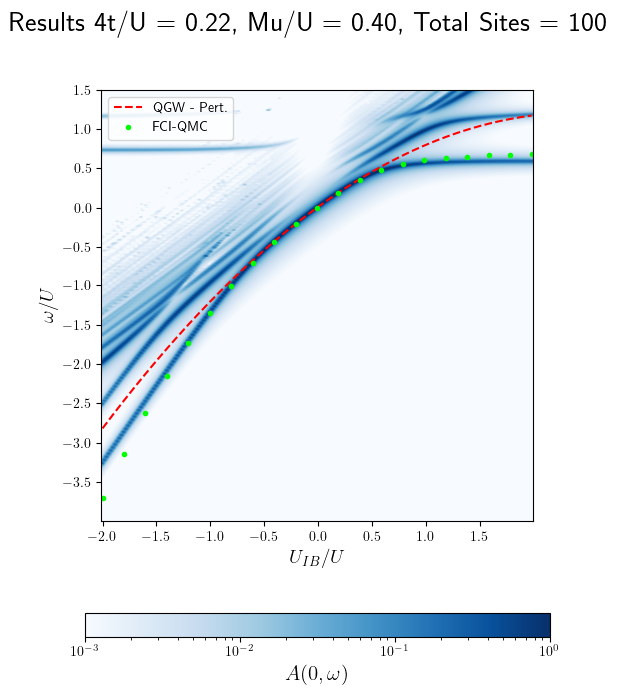

In [6]:

plt.rcParams['text.usetex'] = True

# Rotate the image by -90 degrees
SpectralFuncs_rot = np.rot90(SpectralFuncs, 1)
Sigma_rot = np.rot90(Sigma, 1)
Sigma00_rot = np.rot90(Sigma00, 1)


fig, ax1 = plt.subplots(ncols = 1, figsize = (6,8))

# Create the plot
# Set the aspect ratio to the ratio of the number of x points to the number of y points
aspect_ratio = 0.5#0.5#'auto'#1
color_map = 'Blues'
interp = 'bicubic'
im1 = ax1.imshow(np.abs(SpectralFuncs_rot), interpolation = interp, cmap=color_map, aspect = aspect_ratio, norm=matplotlib.colors.LogNorm())


# Select a subset of dJUs and en_vector for the ticks
num_xticks = 9
#num_yticks = 12
num_yticks = 12#7
xticks = np.linspace(0, SpectralFuncs_rot.shape[1], num_xticks, endpoint=True, dtype=int)
yticks = np.linspace(0, SpectralFuncs_rot.shape[0], num_yticks, endpoint=True, dtype=int)

xticklabels = np.round(np.linspace(min(UIBs), max(UIBs), num_xticks),2)
yticklabels = np.round(np.linspace(max(en_vector), min(en_vector), num_yticks), 2)

# Format the labels in LaTeX
xticklabels = [r'$\mathrm{{{}}}$'.format(label) for label in xticklabels]
yticklabels = [r'$\mathrm{{{}}}$'.format(label) for label in yticklabels]

ax1.set_xticks(xticks)
ax1.set_yticks(yticks)

ax1.set_xticklabels(xticklabels)
ax1.set_yticklabels(yticklabels)

ax1.set_xlabel(r'$U_{IB}/U$', fontsize=14)
ax1.set_ylabel(r'$\omega/U$', fontsize=14)

cb1 = plt.colorbar(im1,orientation="horizontal")
cb1.set_label(label="$A(0,\omega)$",size=15,weight='bold')
im1.set_clim(1e-3,1e0)
#im1.set_clim(0,1)


idx = np.searchsorted(en_vector, 0, side="left") # find \omega = 0

# plot the extrapolated MC data.
#dJU = 0.1292
#muU = 0.41
#M = 100



#X, Y = np.meshgrid(UIBs, omega0s + omega1s + omega2s)
# ax2 = ax.twinx()
# Transform the y-coordinates of the plot to match the image coordinates
plot_x = np.interp(UIBs, (UIBs.min(), UIBs.max()), (0, SpectralFuncs_rot.shape[1]-1))
plot_y = SpectralFuncs_rot.shape[0] - 1 - np.interp(omega0s + omega1s + omega2s, (en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1))
plot_non_T = SpectralFuncs_rot.shape[0] - 1 - np.interp(np.real(Sigma_rot[idx,:]), (en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1))
plot_0 = len(en_vector) - idx + np.zeros(len(plot_y))

# Overlay the plot on top of the imshow figure
fig.suptitle(f"Results 4t/U = {dJU:0.4f}, Mu/U = {muU:0.4f}, Total Sites = {M}", fontsize = 20)
ax1.plot(plot_x, plot_y, linestyle = '--', label='QGW - Pert.', color='red', linewidth=1.5)
#ax1.plot(plot_x, plot_non_T, linestyle = ':', label='NSC:  Ladder', color='white', linewidth=1.5)
#ax1.plot(plot_x, plot_0, linestyle = '-', color='white', linewidth=1.5)
#ax2.plot(plot_x, plot_y, linestyle = '--', label='Perturbative - Rayl. Schr.', color='white', linewidth=1.5)

Ep_M = Ep_M_t_0p075
plot_x = np.interp(UIBs_M, (UIBs_M.min(), UIBs_M.max()), (0, SpectralFuncs_rot.shape[1]-1))
plot_y = SpectralFuncs_rot.shape[0] - 1 - np.interp(Ep_M, (en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1))
fig.suptitle(f"Results 4t/U = {dJU:0.2f}, Mu/U = {muU:0.2f}, Total Sites = {M}", fontsize = 20)
ax1.plot(plot_x, plot_y, '.', label='FCI-QMC', color='lime')

ax1.legend()

plt.show()

In [7]:
## Save the figure 
#filename = f'../figs/Spectral_Line_UIB_Scan/dJU_{dJU}_Mu_{muU:.2f}_M_{grid.M}_N_{N}_num_en_{num_en}_num_UIB_{num_UIB}.pdf'
#filename = f'../figs/self_consistent_t/ladder_full_mf_init/UIB_scan/dJU_{dJU}_Mu_{muU:.2f}_M_{grid.M}_N_{N}_num_en_{num_en}_num_UIB_{num_UIB}_eta_{eta}_cutoff_{cutoff}_n_1_alt_color_log.pdf'
#filename = f'../figs/ladder_approximation/Comparison/mf_shift_dJU_0.2154_Mu_0.39_M_100_N_7_num_en_100_num_UIB_100_eta_0.01_cutoff_3_n_1_alt_color_log.pdf'
filename = f'../figs/self_consistent_t/mean_field/UIB_scan/dJU_{dJU}_Mu_{muU:.2f}_M_{grid.M}_N_{N}_num_en_{num_en}_num_UIB_{num_UIB}_eta_{eta}_cutoff_{cutoff}.pdf'

fig.savefig(filename, dpi=300, bbox_inches='tight')



In [8]:
# Save the data
# Don't run twice!

# Code to save results for different UIBs
#filename = f'./data/Spectral_Line_UIB_Scan/dJU_{dJU}_Mu_{muU:.2f}_M_{grid.M}_N_{N}_num_en_{num_en}_num_UIB_{num_UIB}.hdf5'
#filename = f'./data/ladder_approximation/Comparison/mf_shift_dJU_0.2154_Mu_0.39_M_100_N_7_num_en_100_num_UIB_100_eta_0.01_cutoff_3.hdf5'
filename = f'./data/self_consistent_t/mean_field/UIB_scan/dJU_{dJU}_Mu_{muU:.2f}_M_{grid.M}_N_{N}_num_en_{num_en}_num_UIB_{num_UIB}_eta_{eta}_cutoff_{cutoff}_n_1_alt_color.hdf5'


with h5py.File(filename, 'w') as f:
    f.create_dataset('UIBs', data=UIBs)
    f.create_dataset('en_vector', data=en_vector)
    f.create_dataset('omega0s', data=omega0s)
    f.create_dataset('omega1s', data=omega1s)
    f.create_dataset('omega2s', data=omega2s)
    for i, UIB in enumerate(UIBs):
    # Create a group for this dJU value
        group = f.create_group(f'UIB_{UIB}')

        # Store the arrays in this group
        group.create_dataset('T11', data=T11[i, :])
        group.create_dataset('T12', data=T12[i, :])
        group.create_dataset('T21', data=T21[i, :])
        group.create_dataset('T22', data=T22[i, :])
        group.create_dataset('T22_SE', data=T22_F[i, :])
        group.create_dataset('SE_SI', data=SE_SI[i, :])
    

    # Create attributes for your parameters
    f.attrs['dJU'] = dJU
    f.attrs['muU'] = muU
    f.attrs['Lx'] = grid.Lx
    f.attrs['Ly'] = grid.Ly
    f.attrs['N'] = N


    UIBs = f['UIBs'][:]
    en_vector = f['en_vector'][:]
    omega0s = f['omega0s'][:]
    omega1s = f['omega1s'][:]
    omega2s = f['omega2s'][:]

    T11 = []
    T12 = []
    T21 = []
    T22 = []
    T22_SE = []
    SE_SI = []

    for count, UIB in enumerate(UIBs):
        group = f[f'UIB_{UIB}']
        T11.append(group['T11'][:])
        T12.append(group['T12'][:])
        T21.append(group['T21'][:])
        T22.append(group['T22'][:])
        T22_SE.append(group['T22_SE'][:])
        SE_SI.append(group['SE_SI'][:])